# Машинное обучение, ФКН ВШЭ #

## Практическое задание 5. Решающие деревья ##

### Общая информация ###

Дата выдачи: 16.04.2026

Мягкий дедлайн: 30.04.2026 23:59

Жесткий дедлайн:  05.05.2026 23:59

### О задании

В процессе выполнения этого домашнего задания вы:

1. Попрактикуетесь использовать решающие деревья из `sklearn` для задачи классификации на простых двумерных датасетах, научитесь визуализировать разделяющие плоскости и распознавать переобучение.

2. Реализуете своё решающее дерево для задачи классификации и сравните его со стандартной имплементацией.

3. Исследуете влияние бэггинга на смещение и разброс.

### Оценивание и штрафы

Каждая из задач имеет определенную стоимость, которая указана в скобках около номера задачи. Максимально допустимая оценка за работу $-$ 10 баллов.

Задание выполняется самостоятельно. "Похожие" решения считаются плагиатом: все задействованные студенты (в том числе те, у кого списали) получают не более 0 баллов. Если вы использовали внешний источник (даже частично), укажите ссылку в отдельном блоке в конце работы.

Неэффективная реализация кода может негативно отразиться на оценке.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.


### Формат сдачи

Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-05-trees-Username.ipynb
* Модуль hw5code.py
* Номера лучших посылок в Яндекс.Контесте для обеих задач

В **ССЫЛКА НА КОНТЕСТ** нужно отправить файл hw5code.py с реализованными функциями и классами.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже:

__Оценка:__ 10

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

## Решающие деревья

### Визуализация (1 балл)

Рассмотрим три простых двумерных датасета, сгенерированных с помощью `make_moons`, `make_circles` и `make_classification`.

In [ ]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2,
                        class_sep=0.75, random_state=3, n_redundant=0)
]

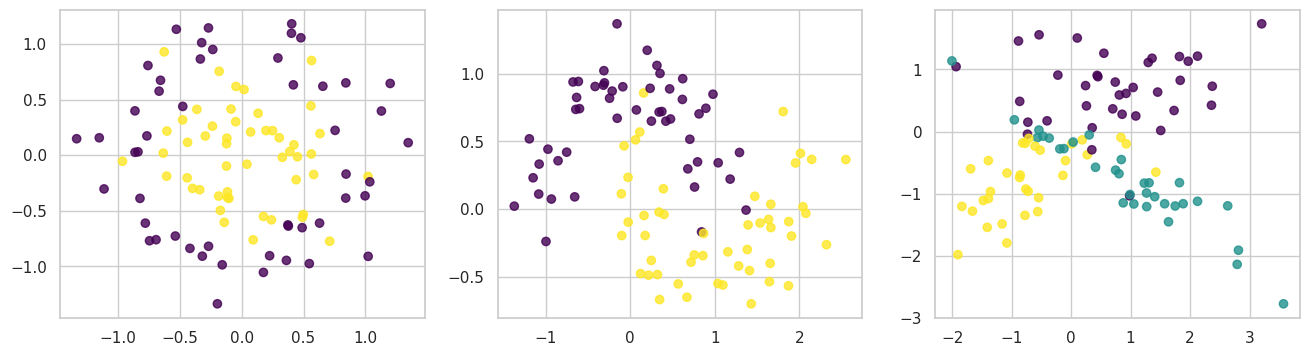

In [ ]:
plt.figure(figsize=(16, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", alpha=0.8)

__Задание 1. (0.5 балла)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности и посчитайте accuracy на обучающей и тестовой выборках. Прокомментируйте, в каких случаях и почему модель переобучается.

circles: depth= 6, leaves=11, train=1.000, test=0.700
moons: depth= 6, leaves=12, train=1.000, test=0.933
classifications: depth= 6, leaves=12, train=1.000, test=0.733


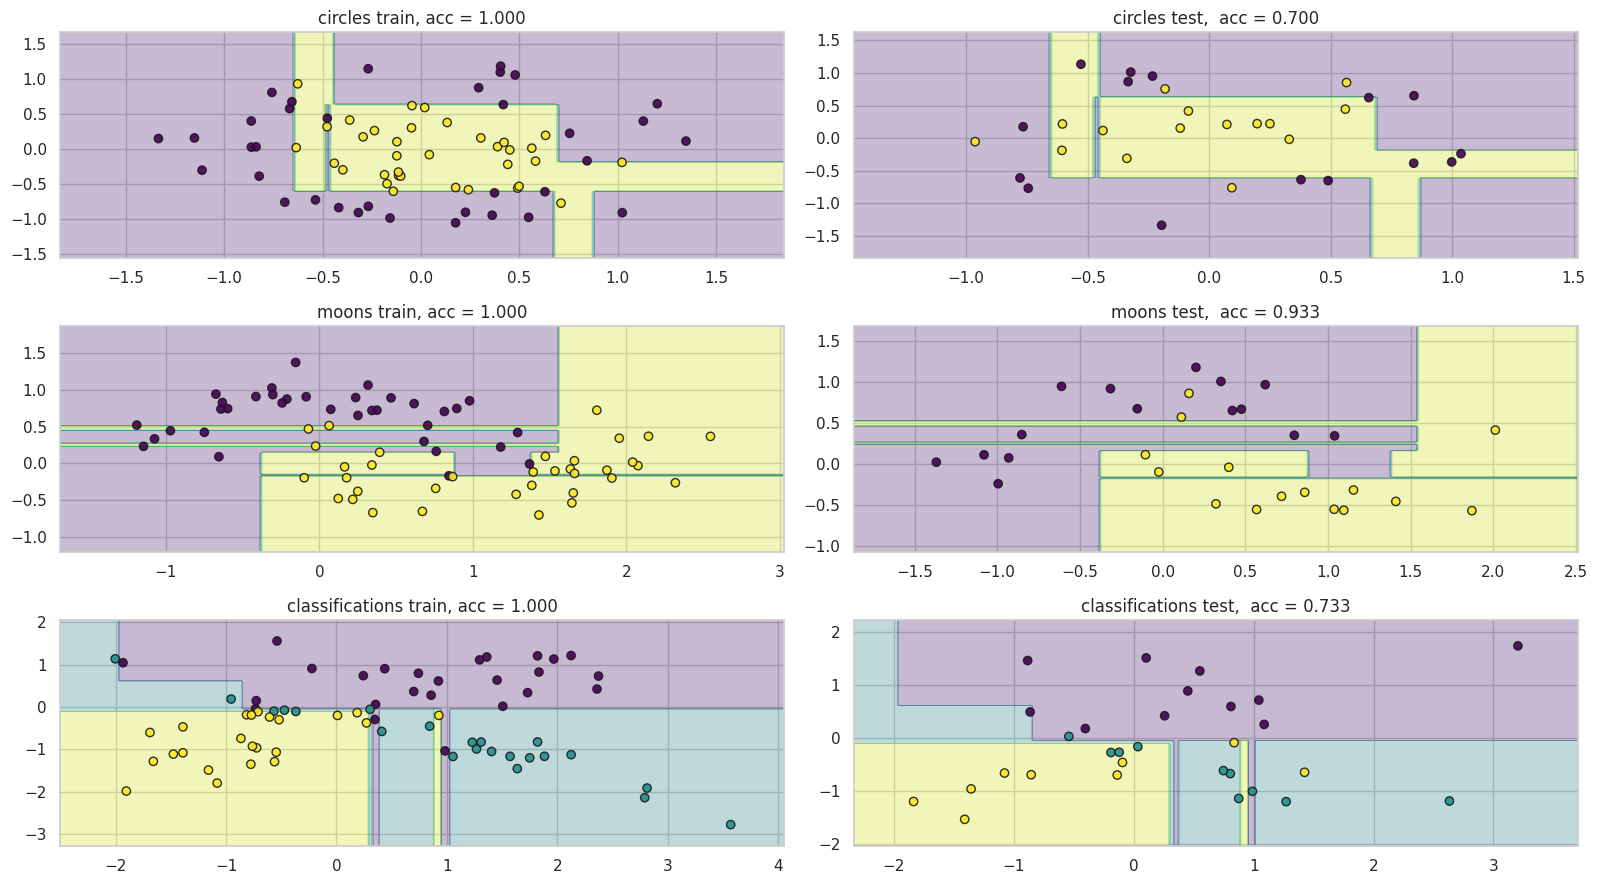

In [ ]:
from sklearn.metrics import accuracy_score

datasets_names = ['circles', 'moons', 'classifications']
fig, axes = plt.subplots(3, 2, figsize=(16, 9))

def plot_decision_surface(clf, X, y, ax, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis',
               edgecolors='k', alpha=0.9)
    ax.set_title(title)

for row, ((X, y), name) in enumerate(zip(datasets, datasets_names)):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    clf = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

    acc_train = accuracy_score(y_train, clf.predict(X_train))
    acc_test = accuracy_score(y_test, clf.predict(X_test))

    plot_decision_surface(clf, X_train, y_train, axes[row, 0],
                          f'{name} train, acc = {acc_train:.3f}')
    plot_decision_surface(clf, X_test, y_test, axes[row, 1],
                          f'{name} test,  acc = {acc_test:.3f}')

    print(f'{name}: depth={clf.get_depth():2d}, '
          f'leaves={clf.get_n_leaves():2d}, '
          f'train={acc_train:.3f}, test={acc_test:.3f}')
plt.tight_layout()
plt.show()

__Ответ:__

Переобучение есть на всех трёх датасетах (train acc = 1). Это случается, потому что дерево с дефолтными параметрами продолжает дробить пространство, пока каждая точка не окажется в своём листе. А насколько переобучилась программа зависит от того, насколько форма настоящей границы мэтчится с прямоугольными разбиениями дерева и насколько сильно классы перекрываются:

1) На circles максимальный разрыв 0.3, потому что круговую границу невозможно точно приблизить прямоугольниками и классы сильно перекрыты.
2) На classification почти также разрыв 0.27 из-за трёх классов и близко расположенных кластеров.
3) На moons минимальный разрыв 0.07, потому что дуги хорошо приближаются ступенчатой границей.

Визуально переобучение выглядит как тонкие полоски одного класса внутри области другого. Они строятся под отдельные шумовые точки train и почти всегда ошибочны на test.



__Задание 2. (0.5 балла)__

Выберите один датасет из предыдущего задания и исследуйте на его примере влияние на итоговое качество двух гиперпараметров (любых на ваш выбор) одновременно. Для каждой пары значений посчитайте accuracy на обучающей и тестовой выборках и сохраните результаты в таблицу.

Визуализируйте зависимость качества на тестовой выборке от значений выбранных вами гиперпараметров. При каких значениях наблюдается лучшее соотношение разброса и смещения? Почему вы сделали такой вывод?

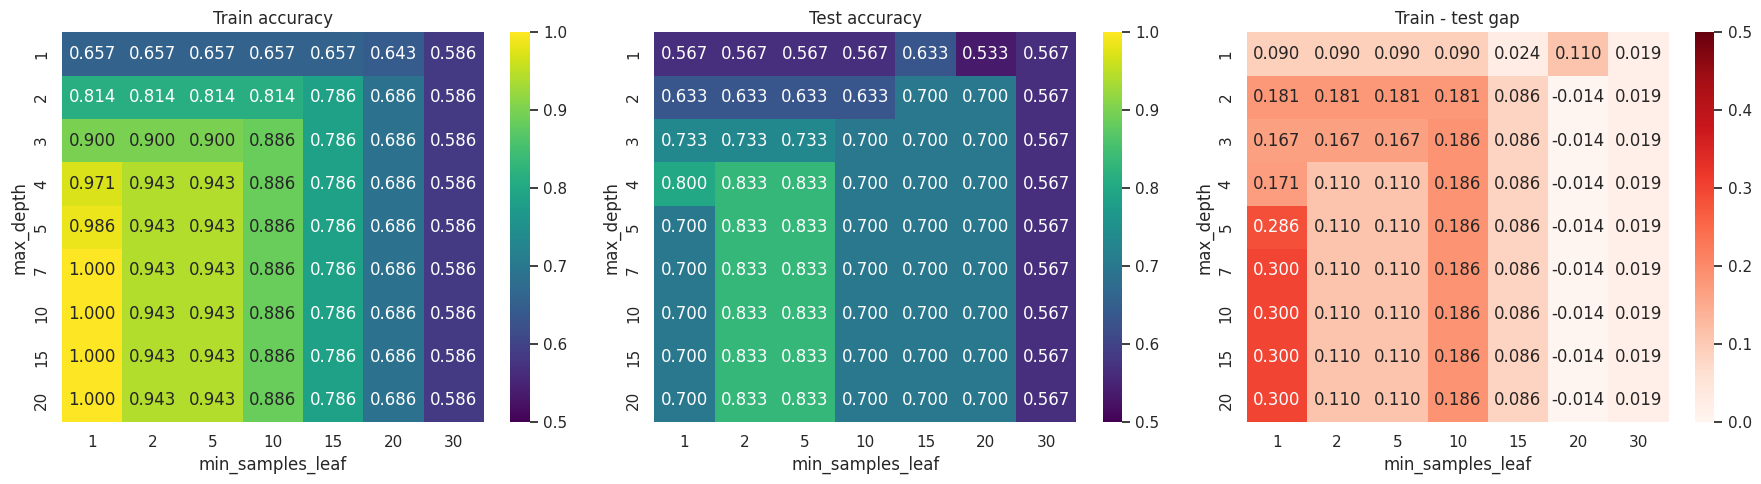

In [ ]:
X, y = datasets[0]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

max_depth_arr = [1, 2, 3, 4, 5, 7, 10, 15, 20]
min_samples_leaf_arr = [1, 2, 5, 10, 15, 20, 30]

arr = []
for md in max_depth_arr:
    for msl in min_samples_leaf_arr:
        clf = DecisionTreeClassifier(
            max_depth=md, min_samples_leaf=msl, random_state=42
        ).fit(X_train, y_train)
        arr.append({
            'max_depth': md if md is not None else 'None',
            'min_samples_leaf': msl,
            'train_acc': accuracy_score(y_train, clf.predict(X_train)),
            'test_acc': accuracy_score(y_test, clf.predict(X_test)),
        })

results = pd.DataFrame(arr)
results['gap'] = results['train_acc'] - results['test_acc']

pivot_train = results.pivot(index='max_depth', columns='min_samples_leaf', values='train_acc')
pivot_test = results.pivot(index='max_depth', columns='min_samples_leaf', values='test_acc')
pivot_gap = results.pivot(index='max_depth', columns='min_samples_leaf', values='gap')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(pivot_train, annot=True, fmt='.3f', cmap='viridis', ax=axes[0], vmin=0.5, vmax=1.0)
axes[0].set_title('Train accuracy')

sns.heatmap(pivot_test, annot=True, fmt='.3f', cmap='viridis', ax=axes[1], vmin=0.5, vmax=1.0)
axes[1].set_title('Test accuracy')

sns.heatmap(pivot_gap, annot=True, fmt='.3f', cmap='Reds', ax=axes[2], vmin=0, vmax=0.5)
axes[2].set_title('Train - test gap')

plt.tight_layout()
plt.show()

In [ ]:
results.sort_values('test_acc', ascending=False)

,max_depth,min_samples_leaf,train_acc,test_acc,gap
30,5,5,0.942857,0.833333,0.109524
29,5,2,0.942857,0.833333,0.109524
22,4,2,0.942857,0.833333,0.109524
23,4,5,0.942857,0.833333,0.109524
43,10,2,0.942857,0.833333,0.109524
...,...,...,...,...,...
34,5,30,0.585714,0.566667,0.019048
55,15,30,0.585714,0.566667,0.019048
48,10,30,0.585714,0.566667,0.019048
62,20,30,0.585714,0.566667,0.019048


__Ответ:__ Лучший баланс bias-variance достигается при max_depth = 4, min_samples_leaf = 5: здесь test accuracy максимален (0.833), train accuracy = 0.943, gap = 0.11. Почему так?

В верхней части карты (малая глубина) и правой части (большой min_samples_leaf) train и test оба низкие - это зона высокого bias: дерево слишком просто

В левом нижнем углу train = 1, но test проседает до 0.7 при gap = 0.3 - это зона высокой дисперсии: дерево запомнило шум и переобучилось

В оптимальной точке модель достаточно простая для основной закономерности (низкий bias), но не переобучается под отдельные шумовые точки благодаря ограничениям на глубину и размер листа

### Решающие деревья своими руками (6 баллов)

Итак, пришло время реализовать свой класс для обучения решающего дерева.

__Задание 3. (1.5 балла)__

Реализуйте функцию `find_best_split` из модуля `hw5code.py` согласно алгоритму, расказанному на лекции; её сигнатура и докстринг с дополнительными требованиями и указаниями прописаны в файле.

Напоминаем, что под критерием Джини подразумевается следующая функция качества разбиения:

$$
Q(R, R_l, R_r) = -\frac{|R_l|}{|R|} H(R_l) - \frac{|R_r|}{|R|} H(R_r),
$$

где $R$ - множество объектов, $R_l$ и $R_r$ - объекты, попавшие в левое и правое поддерево соответственно.

Функция неоднородности Джини для множества $R$ определяется как

$$
H(R) = 1 - \sum_{k=1}^{K} p_k^2,
$$

где $p_k$ - доля объектов класса $k$ в множестве $R$, а $K$ - число различных классов в текущем узле.

Замечание: при $K=2$ формула сводится к бинарному случаю $H(R)=1-p_0^2-p_1^2$, где $p_1$ и $p_0$ $-$ доля объектов классов $1$ и $0$ соответственно.


__Задание 4. (0.75 балл)__

Загрузите датасет [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance). Поработайте с данными: создайте бинарный признак `pass`, который будет равен единице, если итоговая оценка `G3` не меньше $10$, и нулю в противном случае. Затем выберите пять числовых признаков, среди которых должны быть как очень информативные, так и потенциально неинформативные. Коротко обоснуйте свой выбор.

Для каждого из выбранных признаков постройте график зависимости критерия Джини от возможного порога разделения. Отобразите все пять кривых на одном рисунке.

Для каждого из выбранных признаков дополнительно визуализируйте зависимость
"значение признака - класс (0/1)".

> Можно, например, построить scatter-график, где по оси X - значение признака, а по оси Y - бинарный признак `pass` (при необходимости используйте небольшой jitter по оси Y и/или прозрачность alpha, чтобы лучше видеть плотность точек); или использовать эквивалентную по смыслу визуализацию (например, `seaborn.stripplot` / `swarmplot`), из которой видно, как распределены значения признака внутри каждого класса.

In [ ]:
import zipfile
import os

outer = '/content/student+performance.zip'
work_dir = '/content/student_data'
os.makedirs(work_dir, exist_ok=True)

with zipfile.ZipFile(outer) as z:
    z.extractall(work_dir)
inner = os.path.join(work_dir, 'student.zip')

with zipfile.ZipFile(inner) as z:
        z.extractall(work_dir)

print('Файлы:', os.listdir(work_dir))

df = pd.read_csv(os.path.join(work_dir, 'student-mat.csv'), sep=';')
print('Размер датасета:', df.shape)

df['pass'] = (df['G3'] >= 10).astype(int)
print('Распределение классов:')
print(df['pass'].value_counts())

Файлы: ['.student.zip_old', 'student.txt', 'student.zip', 'student-por.csv', 'student-mat.csv', 'student-merge.R']
Размер датасета: (395, 33)
Распределение классов:
pass
1    265
0    130
Name: count, dtype: int64


G2 best threshold = 9.50, best Q = -0.1407
failures best threshold = 0.50, best Q = -0.3945
studytime best threshold = 2.50, best Q = -0.4378
absences best threshold = 13.50, best Q = -0.4314
famrel best threshold = 3.50, best Q = -0.4404


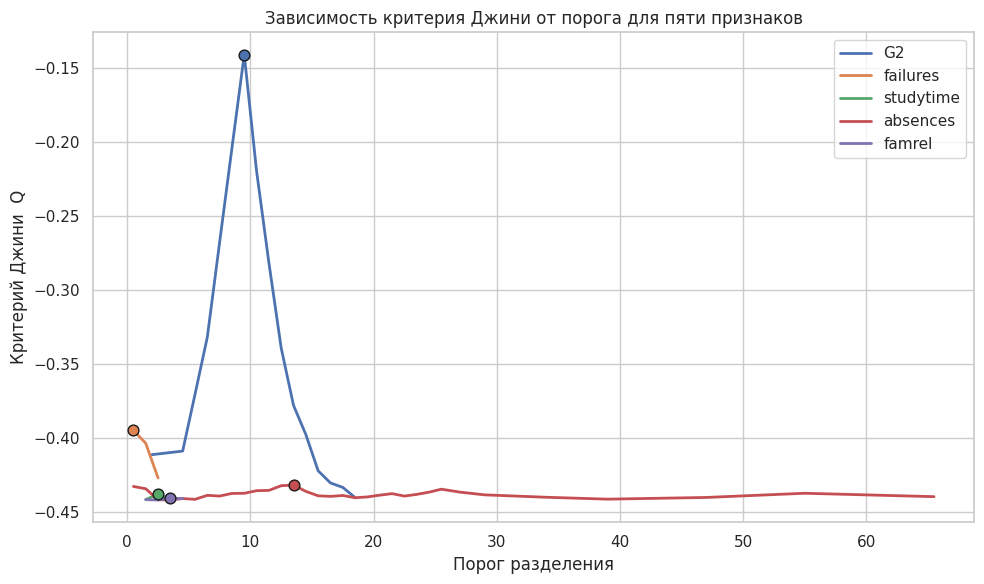

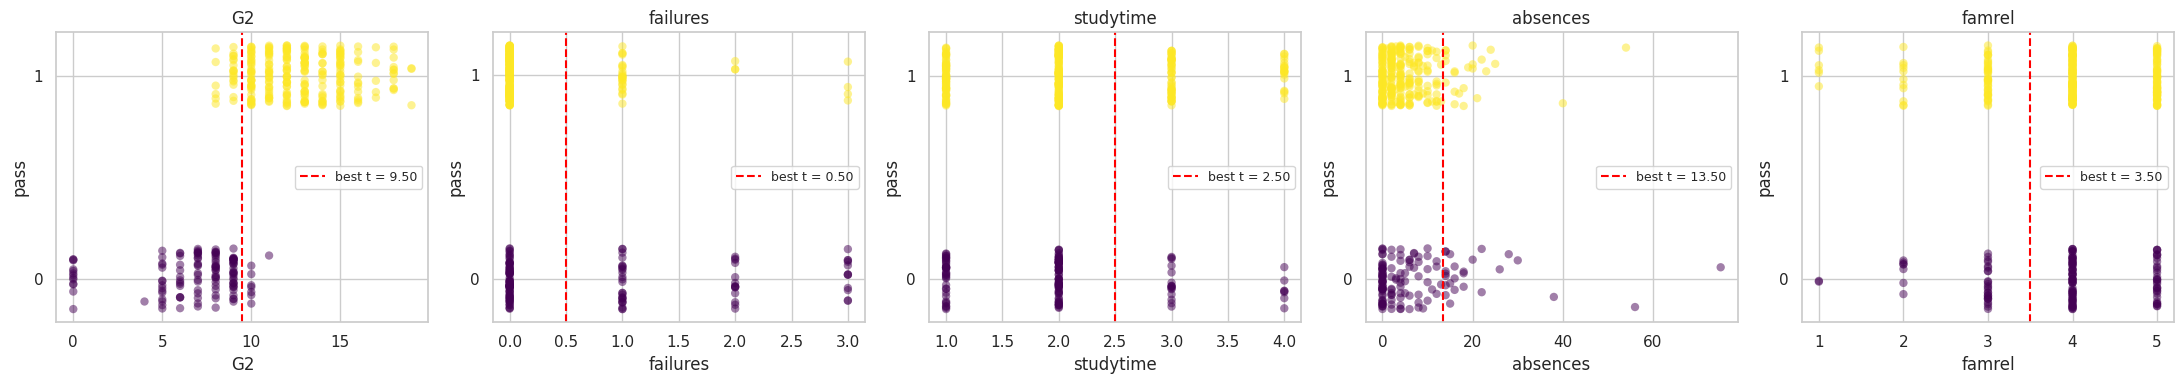

In [ ]:
from hw5code import find_best_split

features = ['G2', 'failures', 'studytime', 'absences', 'famrel']
y = df['pass'].values

curves = {}
for f in features:
    x = df[f].values.astype(float)
    thresholds, ginis, t_best, g_best = find_best_split(x, y)
    curves[f] = (thresholds, ginis, t_best, g_best)
    print(f'{f} best threshold = {t_best:.2f}, best Q = {g_best:.4f}')

plt.figure(figsize=(10, 6))
for f in features:
    thr, g, t_best, g_best = curves[f]
    plt.plot(thr, g, label=f, linewidth=2)
    plt.scatter([t_best], [g_best], s=60, zorder=5, edgecolors='k')
plt.xlabel('Порог разделения')
plt.ylabel('Критерий Джини  Q')
plt.title('Зависимость критерия Джини от порога для пяти признаков')
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
rng = np.random.default_rng(0)
for ax, f in zip(axes, features):
    x = df[f].values.astype(float)
    jitter = rng.uniform(-0.15, 0.15, size=len(y))
    ax.scatter(x, y + jitter, c=y, cmap='viridis',
               alpha=0.5, edgecolors='none')
    t_best = curves[f][2]
    if t_best is not None:
        ax.axvline(t_best, color='red', linestyle='--',
                   label=f'best t = {t_best:.2f}')
        ax.legend(loc='center right', fontsize=9)
    ax.set_xlabel(f)
    ax.set_ylabel('pass')
    ax.set_yticks([0, 1])
    ax.set_title(f)
plt.tight_layout()
plt.show()

__Ответ:__ Результаты полностью подтверждают гипотезу о выборе признаков:

G2 даёт самый глубокий пик Q (−0.141) - это признак, который дает много инфы. На scatter видно, что классы 0 и 1 лежат в разных частях графика с мин перекрытием. Это ожидаемо: G2 - оценка за второй период, почти напрямую предсказывающая итоговую

failures даёт умеренный пик (Q = −0.394). Оптимальный порог 0.5 соответствует содержательному разделению "без провалов vs хотя бы один провал". на scatter'е видно, что сдавшие сильно смещены к failures = 0, тогда как несдавшие распределены по всем значениям. Полезный признак, но слабее G2

studytime, absences и famrel дают кривые Q, практически сливающиеся с базовой линией. На scatter оба класса равномерно представлены по всей шкале каждого из признаков. Эти признаки пояти бесполезны: любое разбиение по ним почти не уменьшает неопределённость.

В итоге гипотеза подтвердилась: G2 и failures и правда являются сильными предикторами, famrel итак не ждали особой ифнормативности от него, а studytime и absences, несмотря на кажущуюся связь с успеваемостью, на практике оказались почти бесполезными

__Задание 5. (0.25 балла)__

На основании построенных в прошлом задании графиков ответьте на следующие вопросы:

1. По какому признаку нужно производить деление выборки на два поддерева? Почему?

2. Согласуется ли этот результат с тем, что видно на scatter-графиках? Совпадают ли выводы?

3. Как выглядят кривые для тех признаков, по которым классы разделяются почти идеально? Чем отличаются от них кривые для признаков, по которым деление практически невозможно?

**Ответ:**
1. Делить нужно по G2 с порогом 9.5

Жадный алгоритм построения решающего дерева выбирает на каждом шаге такое разбиение (j,t), которое максимизирует Q. Среди пяти наших признаков G2 даёт best Q = −0.141, тогда как у остальных значения от −0.394 до −0.440. Разница огромная, G2 снижает неопределённость примерно втрое, а ближайший конкурент failures улучшает Q всего до −0.394

2. Да, полностью согласуется

На scatter G2 классы 0 и 1 визуально разделены по оси X: несдавшие сгруппированы слева , сдавшие - справа. Красная линия порога 9.5 проходит почти по границе облаков и практически не пересекается с точками не того класса.
На scatter остальных признаков облака двух классов накладываются друг на друга по всей шкале

Это визуальное наблюдение и формальный критерий Джини дают идентичный ответ и это не совпадение. Критерий Джини был придуман именно так, чтобы формально отражать то, что мы интуитивно видим на графиках.

3. Как отличаются кривые хороших и плохих признаков

Кривая G2:

Имеет выраженный локальный максимум.
Максимум приходится на порог, который действительно лежит на границе между классами (9.5 - граница между облаками на scatter). Значение в максимуме значительно выше для G2 это −0.141 при базовой линии −0.441.
Форма кривой несимметрична: Q растёт к оптимальному порогу и падает после него.

Кривая плохого признака (famrel, studytime, absences):

Почти плоская, лежит на уровне базовой линии. Никакого выраженного пика нет.
Любой порог даёт разбиение, практически не уменьшающее неопределённости.

Небольшие локальные колебания - шум

Если признак никак не связан с таргетом, то в любой подвыборке, образованной порогом, распределение классов примерно такое же, как в исходной $H(R_l) \approx H(R_r) \approx H(R)$. Тогда

$$Q = -\frac{|R_l|}{|R|} H(R_l) - \frac{|R_r|}{|R|} H(R_r) \approx -H(R)$$

независимо от порога - отсюда и плоскость. Если же признак разделяет классы идеально, то при оптимальном пороге $H(R_l) = H(R_r) = 0$ и $Q = 0$ - отсюда и пик у вершины

__Задание 6. (1.5 балла)__

Разберитесь с уже написанным кодом в классе `DecisionTree` модуля `hw5code.py`. Исправьте ошибки в методе `_fit_node`, а также реализуйте `_predict_node`.

В данном задании:
* построение дерева осуществляется согласно базовому жадному алгоритму, предложенному на лекции
* выбор лучшего разбиения необходимо производить по критерию Джини
* в качестве критерия останова используется следующий: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку
* ответ в листе $-$ это наиболее часто встречающийся в нём класс
* для категориальных признаков выполняется преобразование, описанное на лекции (можете найти его в конспекте в разделе «Учёт категориальных признаков»)

__Задание 7. (0.5 балла)__

Протестируйте написанное вами решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Для этого необходимо скачать таблицу agaricus-lepiota.data и применить к каждому столбцу LabelEncoder, чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец в рассматриваемой таблице $-$ это целевая переменная ('e' $-$ edible, 'p' $-$ poisonous).

Обучите решающее дерево на $50\%$ случайно выбранных объектов и получите предсказания для оставшейся половины. Вычислите accuracy. Если в предыдущих заданиях вы всё сделали корректно, то у вас должно получиться качество очень близкое единице или даже равное ей.

In [ ]:
import zipfile, os
zip_path = '/content/mushroom.zip'
extract_dir = '/content/mushroom_data'
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path) as z:
    z.extractall(extract_dir)

print('Файлы:', os.listdir(extract_dir))

Файлы: ['expanded.Z', 'README', 'Index', 'agaricus-lepiota.names', 'agaricus-lepiota.data']


In [ ]:
from sklearn.preprocessing import LabelEncoder
import importlib, hw5code
importlib.reload(hw5code)
from hw5code import DecisionTree

df = pd.read_csv('/content/mushroom_data/agaricus-lepiota.data', header=None)
print('Размер:', df.shape)
print('Распределение классов:', df[0].value_counts().to_dict())

for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col])

y = df[0].values
X = df.drop(columns=0).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)
feature_types = ['categorical'] * X.shape[1]
tree = DecisionTree(feature_types=feature_types)
tree.fit(X_train, y_train)

pred = tree.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f'Accuracy на тесте: {acc:.4f}')

Размер: (8124, 23)
Распределение классов: {'e': 4208, 'p': 3916}
Accuracy на тесте: 1.0000


__Задание 8. (1 балл)__

Реализуйте в классе `DecisionTree` поддержку параметров `max_depth`, `min_samples_split` и `min_samples_leaf` по аналогии с `sklearn.tree.DecisionTreeClassifier`.

__Задание 9. (0.5 балла)__

Проверьте, спасают эти параметры вас от переобучения.

Для этого **решите при помощи собственной имплементации `DecisionTree`  задачу классификации цвета вина** (color) по его химическим характеристикам на датасете [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality).

Как обычно, случайно разбейте свой датасет на тест-трейн (в отношении 7:3), и далее сравните на них поведение двух деревьев:
- Для первого дерева не используйте параметры из задания 8
- Для второго дерева выберите разумные значения этих параметров (в этом конкретном случае мы рекомендуем `max_depth=8, min_samples_leaf=5, min_samples_split=17`), и постройте дерево с их использованием.
  - Подбирать оптимальные параметры здесь не требуется

Выведите метрики качества классификации. **Что вы наблюдаете, и почему так произошло?**


В качестве sanity check сравните качество работы и структуру вашего второго дерева с результатом стандартной имплементации из `sklearn`. Не забудьте подать ему на вход те же параметры.

**Обратите внимание, что в оригинале таргетом является качество вина; мы же с вами предсказываем его цвет.** В каком-то смысле, это модель-сомелье.


*Андер-сэмплирование данных далее сделано специально, чтобы продемонстрировать должный эффект. Убирать его запрещается.*

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

np.random.seed(0)

wine_quality = fetch_ucirepo(id=186)


In [ ]:

df = wine_quality.data.original.sample(frac=0.1)

X = df.drop(columns=['color'])
y = df['color']


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 650 entries, 5316 to 5545
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         650 non-null    float64
 1   volatile_acidity      650 non-null    float64
 2   citric_acid           650 non-null    float64
 3   residual_sugar        650 non-null    float64
 4   chlorides             650 non-null    float64
 5   free_sulfur_dioxide   650 non-null    float64
 6   total_sulfur_dioxide  650 non-null    float64
 7   density               650 non-null    float64
 8   pH                    650 non-null    float64
 9   sulphates             650 non-null    float64
 10  alcohol               650 non-null    float64
 11  quality               650 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 66.0 KB


In [ ]:
y.info()

<class 'pandas.core.series.Series'>
Index: 650 entries, 5316 to 5545
Series name: color
Non-Null Count  Dtype 
--------------  ----- 
650 non-null    object
dtypes: object(1)
memory usage: 10.2+ KB


In [ ]:
import importlib, hw5code
importlib.reload(hw5code)
from hw5code import DecisionTree

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

y_bin = (y == 'red').astype(int).values
X_arr = X.values
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_bin, test_size=0.3, random_state=0, stratify=y_bin
)
feature_types = ['real'] * X_arr.shape[1]

tree_no_reg = DecisionTree(feature_types=feature_types)
tree_no_reg.fit(X_train, y_train)
pred_no_reg = tree_no_reg.predict(X_test)

tree_reg = DecisionTree(
    feature_types=feature_types,
    max_depth=8, min_samples_leaf=5, min_samples_split=17
)
tree_reg.fit(X_train, y_train)

pred_reg = tree_reg.predict(X_test)
sk_tree = DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, min_samples_split=17, random_state=0)
sk_tree.fit(X_train, y_train)
pred_sk = sk_tree.predict(X_test)

In [ ]:
print('Tree withouth reg:')
print(f'Train accuracy: {accuracy_score(y_train, tree_no_reg.predict(X_train)):.4f}')
print(f'Test  accuracy: {accuracy_score(y_test, pred_no_reg):.4f}')
print(classification_report(y_test, pred_no_reg, target_names=['white', 'red']))

print('Tree with reg:')
print(f'Train accuracy: {accuracy_score(y_train, tree_reg.predict(X_train)):.4f}')
print(f'Test  accuracy: {accuracy_score(y_test, pred_reg):.4f}')
print(classification_report(y_test, pred_reg, target_names=['white', 'red']))

print('sklearn с теми же ограничениями (sanity check):')
print(f'Train accuracy: {accuracy_score(y_train, sk_tree.predict(X_train)):.4f}')
print(f'Test  accuracy: {accuracy_score(y_test, pred_sk):.4f}')
print(classification_report(y_test, pred_sk, target_names=['white', 'red']))

print(f'sklearn: глубина={sk_tree.get_depth()}, листьев={sk_tree.get_n_leaves()}')

Tree withouth reg:
Train accuracy: 1.0000
Test  accuracy: 0.9795
              precision    recall  f1-score   support

       white       0.99      0.99      0.99       148
         red       0.96      0.96      0.96        47

    accuracy                           0.98       195
   macro avg       0.97      0.97      0.97       195
weighted avg       0.98      0.98      0.98       195

Tree with reg:
Train accuracy: 0.9846
Test  accuracy: 0.9487
              precision    recall  f1-score   support

       white       0.94      0.99      0.97       148
         red       0.97      0.81      0.88        47

    accuracy                           0.95       195
   macro avg       0.96      0.90      0.93       195
weighted avg       0.95      0.95      0.95       195

sklearn с теми же ограничениями (sanity check):
Train accuracy: 0.9846
Test  accuracy: 0.9641
              precision    recall  f1-score   support

       white       0.97      0.99      0.98       148
         red     

Неограниченное дерево достигает train accuracy = 1.0, но при этом его test accuracy = 0.979, то есть gap между train и test всего 0.021. Переобучение практически отсутствует. Более того, регуляризованное дерево показывает чуть более низкий test accuracy (0.949), чем неограниченное. На первый взгляд, это противоречит ожидаемому эффекту регуляризации

**Почему регуляризация не помогла:((**

Задача "красное vs белое вино по химическим характеристикам" очень хорошо разделима по двум-трём признакам. Поэтому даже неограниченное дерево быстро находит правильные разбиения в корне и верхних уровнях, а мелкие разбиения в глубине не наносят особого вреда, под который дерево могло бы переобучиться

Регуляризация борется с variance ценой роста bias. Когда variance изначально мала, регуляризация не даёт выигрыша, но всё равно платит цену в виде bias. Это хорошо видно по метрикам отдельных классов: у неограниченного дерева recall для `red` = 0.96, а у регуляризованного = 0.81

Регуляризация - инструмент борьбы с variance. На задачах с сильным сигналом и малым шумом она может давать небольшое ухудшение качества. На более шумных задачах с большей ролью отдельных объектов эти же параметры помогли бы

**Sanity check**

Sklearn с теми же параметрами даёт train accuracy = 0.985, совпадает с моей реализацией, что подтверждает корректность построения дерева. Test accuracy sklearn = 0.964 против 0.949 у моей реализации Финальное дерево sklearn имеет глубину 3 и 8 листьев — то есть max_depth=8 не был по факту ограничением, обе реализации остановились раньше

## Bias-variance decomposition (3 балла)

В этой части задания воспользуемся возможностями бутстрапа для оценки смещения и разброса алгоритмов машинного обучения.

В этом разделе мы будем работать с датасетом `California housing` из `sklearn.datasets.fetch_california_housing`. Это задача регрессии: по признакам района (доход, возраст домов и т.п.) нужно предсказать MedHouseVal - медианная стоимость жилья.

In [ ]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X = california["data"]
y = california["target"]

X.shape, y.shape

((20640, 8), (20640,))

Во всех заданиях этого раздела (задания 10-11) используйте одни и те же данные `X, y` и три стандартные модели из sklearn:

* `LinearRegression`
* `DecisionTreeRegressor`
* `RandomForestRegressor`

Все три модели имеют единый интерфейс, что позволит передавать их в общие функции.


### Вычисление bias и variance (1.5 балл)

На [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2024-fall/lecture-notes/lecture08-ensembles.pdf) была выведена следующая формула, показывающая, как можно представить ошибку алгоритма регрессии в виде суммы трех компонент:
$$
L(\mu) =
    \mathbb{E}_{x, y}\bigl[\mathbb{E}_{X}\bigl[ (y - \mu(X)(x))^2 \bigr]\bigr] =
$$

$$
    \underbrace{\mathbb{E}_{x, y}\bigl[(y - \mathbb{E}[y|x] )^2\bigr]}_{\text{шум}} + \underbrace{\mathbb{E}_{x}\bigl[(\mathbb{E}_{X}[\mu(X)(x)] - \mathbb{E}[y|x] )^2\bigr]}_{\text{смещение}} +
    \underbrace{\mathbb{E}_{x}\bigl[\mathbb{E}_{X}\bigl[(\mu(X)(x) - \mathbb{E}_{X}[\mu(X)(x)] )^2\bigr]\bigr]}_{\text{разброс}},
$$
* $\mu(X)$ — алгоритм, обученный по выборке $X = \{(x_1, y_1), \dots (x_\ell, y_\ell)\}$;
* $\mu(X)(x)$ — ответ алгоритма, обученного по выборке $X$, на объекте $x$;
* $\mathbb{E}_{X}$ — мат. ожидание по всем возможным выборкам;
* $\mathbb{E}_{X}[\mu(X)(x)]$ — "средний" ответ алгоритма, обученного по всем возможным выборкам $X$, на объекте $x$.
    
С помощью этой формулы мы можем анализировать свойства алгоритма обучения модели $\mu$, если зададим вероятностную модель порождения пар $p(x, y)$.

В реальных задачах мы, конечно же, не знаем распределение на парах объект - правильный ответ. Однако у нас есть набор семплов из этого распределения (обучающую выборка), и мы можем использовать его, чтобы оценивать математические ожидания. Для оценки мат. ожиданий по выборкам мы будем пользоваться бутстрэпом - методом генерации "новых" выборок из одной с помощью выбора объектов с возвращением. Разберем несколько шагов на пути к оценке смещения и разброса.

#### **Приближенное вычисление интегралов**

Для большинства моделей данных и алгоритмов обучения аналитически рассчитать математические ожидания в формулах не удастся. Однако мат. ожидания можно оценивать приближенно. Чтобы оценить математическое ожидание $\mathbb{E}_{\bar z} f(\bar z)$ функции от многомерной случайной величины $\bar z = (z_1, \dots, z_d)$, $\bar z \sim p(\bar z)$, можно сгенерировать выборку из распределения $p(\bar z)$ и усреднить значение функции на элементах этой выборки:
$$\mathbb{E}_{\bar z} f(z) = \int f(\bar z) p(\bar z) d \bar z \approx \frac 1 m \sum_{i=1}^m f(\bar z_i), \, \bar z_i \sim p(\bar z), i = 1, \dots, m.$$

Например, оценим $\mathbb{E}_z z^2,$ $z \sim \mathcal{N}(\mu=5, \sigma=3)$ (из теории вероятностей мы знаем, что
$\mathbb{E}_z z^2 = \sigma^2 + \mu^2 = 34$):

In [ ]:
z = np.random.normal(loc=5, scale=3, size=1000)
(z**2).mean()

np.float64(34.23703285619592)

#### **Оценивание $\mathbb{E}_{x, y}$**

Оценить мат. ожидания по $x$ и по $x, y$, встречающиеся во всех трех компонентах разложения, несложно, потому что у нас есть выборка объектов из распределения данных $p(x, y)$:
$$ \mathbb{E}_{x} f(x) \approx \frac 1 N \sum_{i=1}^N f(x_i), \quad
\mathbb{E}_{x, y} f(x, y) \approx \frac 1 N \sum_{i=1}^N f(x_i, y_i),$$
где $N$ - число объектов в выборке, $\{(x_i, y_i)\}_{i=1}^N$ - сама выборка.

#### **Оценивание $\mathbb{E}_X$ с помощью бутстрапа**

Чтобы оценить мат. ожидание по $X$, нам понадобится выборка из выборок:
$$\mathbb{E}_X f(X) \approx \frac 1 s \sum_{j=1}^s f(X_j),$$
где $X_j$ - $j$-я выборка. Чтобы их получить, мы можем воспользоваться бутстрапом - методом генерации выборок на основе выбора объектов с возвращением. Чтобы составить одну выборку, будем $N$ раз выбирать индекс объекта $i \sim \text{Uniform}(1 \dots N)$ и добавлять $i$-ю пару (объект, целевая переменная) в выборку. В результате в каждой выборке могут появиться повторяющиеся объекты, а какие-то объекты могут вовсе не войти в некоторые выборки.

**Почему именно выбор с возвращением?**

В классическом бутстрапе мы считаем, что единственное, что у нас есть про распределение данных $p(x, y)$, - это эмпирическое распределение на нашей выборке: каждый объект имеет вероятность $1/N$. Тогда "новая" обучающая выборка размера $N$ моделируется как $N$ независимых выборов *с возвращением* из этого эмпирического распределения.

Отсюда появляются:
* повторы объектов в бутстрап-выборке,
* и, наоборот, out-of-bag объекты, которые в конкретную бутстрап-выборку не попали.

Повторы не являются ошибкой или "зашумлением" эксперимента - они как раз и отражают то, насколько алгоритм чувствителен к конкретным объектам (в том числе к выбросам). Если бы мы каждый раз просто брали подвыборки без возвращения, мы бы изучали уже немного другую процедуру (скорее subsampling / k-fold CV), а не классический бутстрап.

#### **Итоговый алгоритм оценки смещения и разброса алгоритма $a$**
1. Сгенерировать $s$ выборок $X_j$ методом бутстрапа.
1. На каждой выборке $X_j$ обучить алгоритм $a_j$.
1. Для каждой выборки $X_j$ определить множество объектов $T_j$, не вошедших в нее (out-of-bag). Вычислить предсказания алгоритма $a_j$ на объектах $T_j$.

Поскольку у нас есть только один ответ для каждого объекта, мы будем считать шум равным 0, а $\mathbb{E}[y|x]$ равным имеющемуся правильному ответу для объекта $x$.

Итоговые оценки:
* Смещение: для одного объекта - квадрат разности среднего предсказания и правильного ответа. Среднее предсказание берется только по тем алгоритмам $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего смещения выполнить усреденение смещений по объектам.
* Разброс: для одного объекта - выборочная дисперсия предсказаний алгоритмов $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего разброса выполнить усреденение разбросов по объектам.
* Ошибка $L$: усреднить квадраты разностей предсказания и правильного ответа по всем выполненным предсказаниям для всех объектов.

В результате должно получиться, что ошибка приблизительно равна сумме смещения и разброса!

Алгоритм также вкратце описан по [ссылке](https://web.engr.oregonstate.edu/~tgd/classes/534/slides/part9.pdf) (слайды 19-21).

__Задание 10.1 (1 балл)__

Реализуйте описанный алгоритм. Обратите внимание, что если объект не вошел ни в одну из out-of-bag выборок, учитывать его в вычислении итоговых величин не нужно. Как обычно, разрешается использовать только один цикл - по выборкам (от 0 до num_runs-1).

In [ ]:
from sklearn.base import clone

def compute_biase_variance(model, X, y, num_runs=1000):

    """
    :param model: sklearn estimator with fit(...) and predict(...) method
    :param X: numpy-array representing training set ob objects, shape [n_obj, n_feat]
    :param y: numpy-array representing target for training objects, shape [n_obj]
    :param num_runs: int, number of samples (s in the description of the algorithm)

    :returns: bias (float), variance (float), error (float)
    each value is computed using bootstrap
    """

    X = np.asarray(X)
    y = np.asarray(y, dtype=float)
    N = X.shape[0]

    oob_count = np.zeros(N, dtype=np.int64)
    pred_sum = np.zeros(N, dtype=np.float64)
    pred_sq_sum = np.zeros(N, dtype=np.float64)

    rng = np.random.default_rng(0)

    for _ in range(num_runs):
        boot_idx = rng.integers(0, N, size=N)

        in_bag_mask = np.zeros(N, dtype=bool)
        in_bag_mask[boot_idx] = True
        oob_idx = np.where(~in_bag_mask)[0]

        if len(oob_idx) == 0:
            continue

        m = clone(model)
        m.fit(X[boot_idx], y[boot_idx])

        preds = m.predict(X[oob_idx])

        oob_count[oob_idx] += 1
        pred_sum[oob_idx] += preds
        pred_sq_sum[oob_idx] += preds ** 2

        has_oob = oob_count > 0

    n = oob_count[has_oob].astype(np.float64)
    s_pred = pred_sum[has_oob]
    s_pred_sq = pred_sq_sum[has_oob]
    y_true = y[has_oob]

    mean_pred = s_pred / n
    bias_per_obj = (mean_pred - y_true) ** 2
    bias = float(bias_per_obj.mean())
    var_per_obj = s_pred_sq / n - mean_pred ** 2
    variance = float(var_per_obj.mean())

    err_sum = s_pred_sq - 2.0 * y_true * s_pred + n * y_true ** 2
    error = float(err_sum.sum() / n.sum())

    return bias, variance, error

__Задание 10.2 (0.25 баллов)__

Оцените смещение, разброс и ошибку для трех алгоритмов с гиперпараметрами по умолчанию: линейная регрессия, решающее дерево, случайный лес.

Проанализируйте полученный результат. Согласуются ли полученные результаты с теми, что обсуждались на занятиях?

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = [
    ('LinearRegression', LinearRegression()),
    ('DecisionTreeRegressor', DecisionTreeRegressor(random_state=0)),
    ('RandomForestRegressor', RandomForestRegressor(random_state=0, n_jobs=-1)),
]

for name, m in models:
    bias, var, err = compute_biase_variance(m, X, y, num_runs=100)
    print(f'{name}: bias={bias:.4f}, variance={var:.4f}, error={err:.4f}')

LinearRegression: bias=0.5353, variance=0.0276, error=0.5650
DecisionTreeRegressor: bias=0.2496, variance=0.2942, error=0.5434
RandomForestRegressor: bias=0.2470, variance=0.0184, error=0.2656


**Ответ:** Результаты согласуются

LinearRegression - высокий bias, очень низкий variance. Линейная модель жёсткая и не способна выучить нелинейные зависимости в данных, отсюда большой bias. Зато на разных бутстрапах получаются почти одинаковые модели, поэтому variance минимальный. Это underfit-модель

DecisionTreeRegressor - низкий bias, высокий variance. Дерево с дефолтными параметрами растёт до полного запоминания обучающей выборки, поэтому в среднем по бутстрапам его предсказание близко к правильному ответу - bias почти такой же, как у леса. Но конкретное дерево очень сильно зависит от того, какие именно объекты попали в обучение: одна-две точки могут радикально изменить структуру разбиений в нижних узлах. Это overfit-модель

RandomForestRegressor - низкий bias и низкий variance. Bias почти такой же, как у одиночного дерева, а variance упал сильно относительно одиночного дерева. Это и есть главный эффект бэггинга: усреднение предсказаний по 100 деревьям, обученным на разных бутстрап-выборках, резко снижает дисперсию итогового прогноза, не повышая смещения. В итоге Random Forest даёт в два раза меньшую ошибку, чем остальные модели

Преимущество Random Forest над одиночным деревом проявляется именно в variance, а не в bias. Бэггинг не учит новой модели, а уменьшает разброс уже существующей

__Задание 10.3 (0.25 баллов)__
Постройте бэггинг над всеми тремя моделями (линейная регрессия, решающее дерево, случайный лес). Вспомните обсуждение с лекции о том, во сколько раз в теории бэггинг уменьшает разброс базового алгоритма. Выполняется ли это в ваших экспериментах? Если нет, поясните, почему.

**Ответ:**

In [ ]:
from sklearn.ensemble import BaggingRegressor

bagged_models = [
    ('Bagging (LinearRegression)',
     BaggingRegressor(estimator=LinearRegression(), n_estimators=10, random_state=0, n_jobs=-1)),
    ('Bagging (DecisionTree)',
     BaggingRegressor(estimator=DecisionTreeRegressor(random_state=0), n_estimators=10, random_state=0, n_jobs=-1)),
    ('Bagging (RandomForest)',
     BaggingRegressor(estimator=RandomForestRegressor(n_estimators=20, random_state=0,n_jobs=-1), n_estimators=10, random_state=0)),
]

for name, m in bagged_models:
    bias, var, err = compute_biase_variance(m, X, y, num_runs=50)
    print(f'{name}: bias={bias:.4f}, variance={var:.4f}, error={err:.4f}')

Bagging (LinearRegression): bias=0.5890, variance=0.0624, error=0.6636
Bagging (DecisionTree): bias=0.2490, variance=0.0439, error=0.2930
Bagging (RandomForest): bias=0.2559, variance=0.0106, error=0.2666


По теории бэггинг из 10 независимых моделей должен снижать variance в 10 раз. На практике этого не происходит из-за корреляции между базовыми моделями

Bagging(LinearRegression) - variance не уменьшилась, а выросла. Линейная регрессия - стабильный детерминированный алгоритм: при заданных данных решение единственное и устойчиво к удалению/добавлению нескольких объектов. Поэтому 10 регрессий, обученных на пересекающихся бутстрап-выборках, оказываются практически идентичными - корреляция между ними близка к 1, и формула $\text{Var}(\bar{a}) = \rho \sigma^2 + \frac{1-\rho}{n}\sigma^2$ упирается в $\rho \sigma^2$, не давая существенного снижения. Поэтому variance каждой модели в бэггинге сама по себе выше исходной, а усреднение это не компенсирует. Бэггинг на стабильных алгоритмах бесполезен

Bagging(DecisionTree) - variance упал в 7 раз, ближе всех к теоретическому пределу. Деревья наиболее нестабильный из трёх алгоритмов: малое изменение обучающей выборки может радикально перестроить разбиения. Поэтому деревья на разных бутстрап-выборках действительно различаются, корреляция между ними заметно меньше единицы, и бэггинг даёт сильный выигрыш. Снижение в 7 раз вместо теоретических 10 - ровно то, что предсказывает теория с учётом ненулевой корреляции

Bagging(RandomForest) - variance упала всего в 1.6 раза. Random Forest - это уже бэггинг, и его исходная variance уже очень мала (0.018). Дополнительный бэггинг не дает особого результата. Леса, обученные на разных бутстрапах, оказываются сильно скоррелированными (потому что внутри каждого уже происходит усреднение по 100/10 деревьям, что уравнивает результаты). Соответственно, выигрыш от внешнего усреднения мал - что подтверждает общий принцип: чем меньше variance у базовой модели, тем меньше пользы от бэггинга над ней.

Теоретическое снижение в n раз требует независимости базовых моделей, чего на практике не достичь - модели обучены на пересекающихся данных и потому скоррелированы. Реальный выигрыш от бэггинга тем больше, чем нестабильнее базовый алгоритм

### Визуализация предсказаний базовых алгоритмов бэггинга (1.5 балл)

Мы уже неоднократно обращались к известной иллюстрации, визуализирующей алгоритмы с разным смещением и разбросом.

![](https://nvsyashwanth.github.io/machinelearningmaster/assets/images/bias_variance.jpg)

В этом задании вам предстоит построить похожее изображение для трёх алгоритмов. Вы будете решать задачу одномерной регрессии, поэтому ваши итоговые мишени будут одномерными.

__Задание 11.1 (1 балл)__

Реализуйте функцию `plot_predictions`, которая должна выполнять следующие шаги:

1. Выбор подмножества данных. Случайным образом выберите num_test_objects пар "объект-целевая переменная" из исходных данных X, y. Выбранные объекты образуют тестовую выборку X_test, y_test, остальные - обучающую выборку X_train, y_train.

2. Метод бутстрапа. Сгенерируйте методом бутстрапа num_runs новых выборок из X_train, y_train. На каждой такой выборке обучите алгоритм и сделайте предсказания для объектов X_test.

3. Построение графика. Нарисуйте scatter-график, где по оси абсцисс - номера тестовых объектов от 0 до num_test_objects - 1 (а не сами значения признаков); по оси ординат - предсказания моделей на этих объектах. В итоге должно получиться num_test_objects вертикальных столбиков из точек: для каждого тестового объекта его num_runs предсказаний.

   Для каждого тестового объекта:
   * отметьте все предсказания для него одним цветом (чтобы был виден столбик);
   * истинный ответ y_test для этого объекта отметьте чёрной точкой.

Не забудьте подписать оси, а также добавить заголовок графика.

> *Примечание.* Раскраска предсказаний по тестовым объектам нужна только для удобства: так легче визуально отличать столбики друг от друга. Можно также сделать все предсказания одного цвета, а истинные значения - чёрными.
>
> Если хотите более явно увидеть bias–variance, можно дополнительно построить второй график, где по оси X - номера тестовых объектов, а по оси Y - разница `mean_pred(x_i) − y_i` (оценка bias), и, например, показать разброс предсказаний в виде вертикальных отрезков или доверительных интервалов.
>
> При больших значениях num_runs вместо (или вместе с) отдельных точек допустимо использовать boxplot/violinplot.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.base import clone

def plot_predictions(model, X, y, num_runs=100, num_test_objects=10, title="", ax=None, test_idx=None, boot_indices=None):
    """
    plot graphics described above
    """
    X = np.asarray(X)
    y = np.asarray(y, dtype=float)
    N = X.shape[0]
    rng = np.random.default_rng(0)

    if test_idx is None:
        test_idx = rng.choice(N, size=num_test_objects, replace=False)
    train_mask = np.ones(N, dtype=bool)
    train_mask[test_idx] = False

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_idx], y[test_idx]
    n_train = X_train.shape[0]

    if boot_indices is None:
        boot_indices = [rng.integers(0, n_train, size=n_train) for _ in range(num_runs)]

    predictions = np.zeros((num_runs, num_test_objects))
    for j in range(num_runs):
        m = clone(model)
        m.fit(X_train[boot_indices[j]], y_train[boot_indices[j]])
        predictions[j] = m.predict(X_test)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(12, 6))

    cmap = plt.get_cmap('tab10')
    x_positions = np.arange(num_test_objects)

    for i in range(num_test_objects):
        ax.scatter(np.full(num_runs, i), predictions[:, i],
                   color=cmap(i % 10), alpha=0.5, s=25)
    ax.scatter(x_positions, y_test, color='black', s=80,
               zorder=5, label='истинное y')

    ax.set_xlabel('номер тестового объекта')
    ax.set_title(title)
    ax.set_xticks(x_positions)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

    if own_fig:
        ax.set_ylabel('предсказание')
        plt.tight_layout()
        plt.show()

__Задание 11.2 (0.5 балла)__

Нарисуйте графики для линейной регрессии, решающего дерева и случайного леса в строчку с одинаковой осью ординат. Это поможет корректно проанализировать масштаб разброса у каждого из этих алгоритмов.

Для каждого графика прокомментируйте, как он характеризует смещение и разброс соответствующего алгоритма.

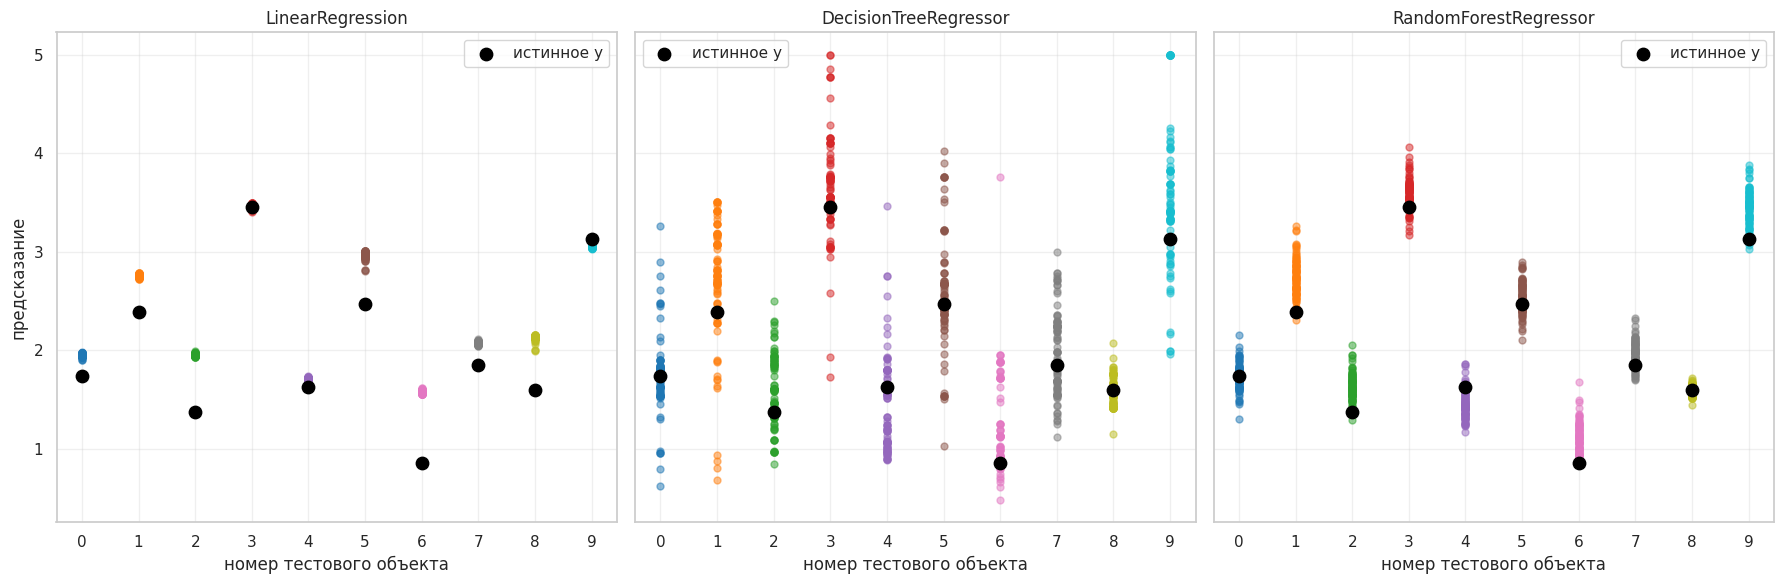

In [ ]:
rng = np.random.default_rng(0)
N = X.shape[0]
test_idx = rng.choice(N, size=10, replace=False)
n_train = N - 10
boot_indices = [rng.integers(0, n_train, size=n_train) for _ in range(100)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

models = [
    (LinearRegression(), 'LinearRegression'),
    (DecisionTreeRegressor(random_state=0), 'DecisionTreeRegressor'),
    (RandomForestRegressor(n_estimators=20, random_state=0, n_jobs=-1), 'RandomForestRegressor'),
]

for ax, (model, title) in zip(axes, models):
    plot_predictions(model, X, y, num_runs=100, num_test_objects=10,
                     title=title, ax=ax,
                     test_idx=test_idx, boot_indices=boot_indices)

axes[0].set_ylabel('предсказание')
plt.tight_layout()
plt.show()

**Ответ:**

LinearRegression

Каждый столбик представляет собой очень компактную группу точек. Это означает, что 100 линейных регрессий, обученных на разных бутстрап выборках, дают почти одинаковые предсказания для каждого тестового объекта. Это визуальное подтверждение низкой variance: линейная модель - устойчивый алгоритм, изменение обучающей выборки слабо меняет коэффициенты

При этом чёрная точка в нескольких случаях находится далеко от столбика.
Это высокий bias: линейная регрессия не может выучить нелинейные зависимости, и для объектов, которые выпадают из общего линейного тренда, она систематически ошибается. Картинка соответствует low variance, high bias.

DecisionTreeRegressor

Столбики значительно шире, чем у линейной регрессии. Для большинства объектов разброс предсказаний составляет 1.5–2.5 единицы по вертикали. Это визуальное подтверждение высокой variance: дерево очень чувствительно к составу обучающей выборки

При этом чёрные точки в среднем находятся внутри столбиков, ближе к их центру. Это низкий bias: дерево не имеет систематического смещения, его ошибка приходит именно от случайной чувствительности к выборке, а не от неспособности выучить закономерность
Картинка соответствует high variance, low bias

RandomForestRegressor

Столбики узкие, как у LinearRegression, но при этом центрированы около чёрных точек, как у дерева

Усреднение по 20 деревьям внутри каждого леса убирает шум индивидуальных деревьев, и итоговая модель получается устойчивой (низкая variance), сохраняя при этом гибкость дерева в выучивании нелинейностей (низкий bias). 100 лесов на разных бутстрап-выборках дают почти одинаковые ответы, и эти ответы близки к истине

Картинка соответствует low variance, low bias